In [ ]:
!pip install langchain langchain_core langgraph langchain_community langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
from typing import TypedDict, Dict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
import music21
import tempfile
import  random

##1. State Defination


In [ ]:
class MusicState(TypedDict):
  musician_input: str
  melody: str
  harmony: str
  rhythm: str
  style: str
  composition: str
  midi_file: str

##2. LLM Initialization

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    temperature = 0,
    groq_api_key = "API KEY PATH",
    model_name = "llama-3.3-70b-versatile"
)
result = llm.invoke("What is music?")

In [ ]:
result.content

'Music is a universal language that has been a part of human culture for thousands of years. It is a form of artistic expression that uses sound and silence to convey emotions, ideas, and experiences. Music can be defined in various ways, but here are some key aspects:\n\n1. **Sound and Silence**: Music is created by combining sounds of different pitches, rhythms, and timbres (tone colors) with periods of silence. These sounds can be produced by various instruments, voices, or electronic means.\n2. **Melody, Harmony, and Rhythm**: Music typically consists of three main elements:\n\t* **Melody**: A succession of pitches heard in sequence, creating a musical line.\n\t* **Harmony**: The combination of multiple pitches sounding simultaneously, creating chords and textures.\n\t* **Rhythm**: The pattern of duration and accentuation of sounds, creating a sense of pulse and meter.\n3. **Emotional Expression**: Music is often used to evoke emotions, convey moods, and tell stories. It can be joy

###3. Musical Node Functions

In [ ]:
def melody_generator(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Generate a melody based on this input:{input}.Represent it as a string of notes in music21 format"
  )
  chain = prompt | llm
  melody = chain.invoke({"input":state["musician_input"]})
  return {"melody":melody.content}

def harmony_creator(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Create harmony for this melody:{melody}.Represent it as a string of chords in music21 format"
  )
  chain = prompt | llm
  harmony = chain.invoke({"melody":state["melody"]})
  return {"harmony":harmony.content}

def rhythm_analyzer(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Analyze and suggest a rhythm for this melody and harmony:{melody},{harmony}.Represent it as a string of duration in music21 format"
  )
  chain = prompt | llm
  rhythm = chain.invoke({"melody":state["melody"],"harmony":state["harmony"]})
  return {"rhythm":rhythm.content}

def style_adapatator(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Adapt this composition to the {style} style:Melody:{melody},Harmony:{harmony},Rhythm:{rhythm}. Provide the result in music21 fromat"
  )
  chain = prompt | llm
  adapted = chain.invoke(
      {
          "style":state["style"],
          "melody":state["melody"],
          "harmony":state["harmony"],
          "rhythm":state["rhythm"]
      }
  )
  return {"composition":adapted.content}

##4. MIDI Conversion

In [ ]:
def midi_convertor(state: MusicState) -> Dict:
    piece = music21.stream.Score()
    # The composition from the LLM is currently a descriptive string, not a parsable music21 object.
    # Therefore, this line is kept for completeness but won't be musically meaningful until LLM output format changes.
    description = music21.expressions.TextExpression(state["composition"])
    piece.append(description)

    scales = {
        'C major': ['C','D','E','F','G','A','B'],
        'C minor': ['C','D','Eb','F','G','Ab','Bb'],
        'C harmonic minor': ['C','D','Eb','F','G','Ab','B'],
        'C melodic minor': ['C','D','Eb','F','G','A','B'],
        'C dorian': ['C','D','Eb','F','G','A','Bb'],
        'C phrygian': ['C','Db','Eb','F','G','Ab','Bb'],
        'C lydian': ['C','D','E','F#','G','A','B'],
        'C mixolydian': ['C','D','E','F','G','A','Bb'],
        'C locrian': ['C','Db','Eb','F','G','Ab','Bb'],
        'C whole tone': ['C','D','E','F#','G#','A#'],
        'C diminished': ['C','D','Eb','F','Gb','Ab','A','B'],
    }

    chords = {
        'C major': ['C4','E4','G4'],
        'C minor': ['C4','Eb4','G4'],
        'C diminished': ['C4','Eb4','Gb4'],
        'C augmented': ['C4','E4','G#4'],
        'C dominant 7th': ['C4','E4','G4','Bb4'],
        'C major 7th': ['C4','E4','G4','B4'],
        'C minor 7th': ['C4','Eb4','G4','Bb4'],
        'C half diminished 7th': ['C4','Eb4','Gb4','Bb4'],
        'C fully diminished 7th': ['C4','Eb4','Gb4','A4'],
    }

    # Correctly defined helper functions
    def create_melody_stream(scale_name, duration):
        melody_part = music21.stream.Part()
        scale = scales[scale_name]
        for i in range(duration):
            note = music21.note.Note(random.choice(scale) + '4') # Fixed: assigned to 'note'
            note.quarterLength = 1
            melody_part.append(note)
        return melody_part

    def create_chord_progression_stream(duration):
        harmony_part = music21.stream.Part()
        for i in range(duration):
            chords_name = random.choice(list(chords.keys()))
            chord = music21.chord.Chord(chords[chords_name])
            chord.quarterLength = 1
            harmony_part.append(chord)
        return harmony_part

    user_input = state["musician_input"].lower()
    if "major" in user_input:
        scale_name = 'C major'
    elif "minor" in user_input:
        scale_name = 'C minor'
    else:
        scale_name = random.choice(list(scales.keys()))

    melody = create_melody_stream(scale_name, 10)
    harmony = create_chord_progression_stream(10) # Fixed typo: create_chords_progression -> create_chord_progression

    final_note = music21.note.Note(scales[scale_name][0]+'4')
    final_note.quarterLength = 1
    melody.append(final_note)

    # Simplified final_chords logic assuming scale_name is a direct key in chords
    # or using a fallback if not.
    # The previous logic `chords[scale_name.split()][0] + ' ' + scale_name.split()[1]` was prone to error.
    try:
        final_chords = music21.chord.Chord(chords[scale_name])
    except KeyError:
        # Fallback for scales like 'C harmonic minor' that don't have direct chord keys
        final_chords = music21.chord.Chord(chords['C major']) # Default to C major chord

    final_chords.quarterLength = 1
    harmony.append(final_chords)


    piece.append(melody)
    piece.append(harmony)

    piece.insert(0, music21.tempo.MetronomeMark(number=60)) # Fixed typo: peice -> piece

    with tempfile.NamedTemporaryFile(delete=False, suffix='.mid') as temp_midi:
        piece.write('midi',temp_midi.name)
        midi_filepath = temp_midi.name # Store path before return
    return{'midi_file':midi_filepath}

##5. LangGraph WorkFlow

In [ ]:
workflow = StateGraph(MusicState)

workflow.add_node("melody_generator",melody_generator)
workflow.add_node("harmony_creator",harmony_creator)
workflow.add_node("rhythm_analyzer",rhythm_analyzer)
workflow.add_node("style_adapatator",style_adapatator)
workflow.add_node("midi_convertor",midi_convertor)

workflow.set_entry_point("melody_generator")

workflow.add_edge("melody_generator","harmony_creator")
workflow.add_edge("harmony_creator","rhythm_analyzer")
workflow.add_edge("rhythm_analyzer","style_adapatator")
workflow.add_edge("style_adapatator","midi_convertor")
workflow.add_edge("midi_convertor",END)

app = workflow.compile()

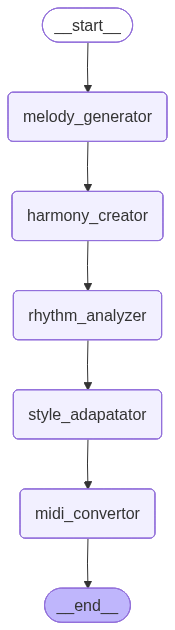

In [ ]:
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image


display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

##6. Run the WorkFlow

In [ ]:
inputs = {
    "musician_input":"Write a sorrow string quartet in C minor",
    "style":"Romantic era"
}

result = app.invoke(inputs)
print(f"MIDI File Saved in {result['midi_file']}")

MIDI File Saved in /tmp/tmpjpdfl8pe.mid


In [ ]:
!apt install fluidsynth
!cp /usr/share/sounds/sf2/FluidR3_GM.sf2 font.sf2
!fluidsynth -ni font.sf2 {result['midi_file']} -F output.wav -r 44100

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fluidsynth is already the newest version (2.2.5-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file 'output.wav'..


In [ ]:
from IPython.display import Audio
Audio(filename="output.wav")